# Code fine-tune mô hình với LoRA 

In [2]:
pip install trl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.6/721.6 kB 14.4 MB/s eta 0:00:0000:01
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Bước 1
# Load thư viện & khai báo hằng số
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, TrainingArguments
from peft import LoraConfig
from trl import SFTTrainer, SFTConfig
from datasets import load_dataset
from huggingface_hub import login

MODEL_NAME = "Qwen/Qwen2.5-3B-Instruct"
OUTPUT_DIR = "/kaggle/working/qwen3b"
HF_TOKEN = "" # Fill your Huggingface Access Tokens here
CHECKPOINT_DIR = "" # This path is used to load the current checkpoint. If you dont have any checkpoints, just let it null.

login(HF_TOKEN)

In [3]:
# Bước 2
# Load training set và validation set

dataset = load_dataset("json", data_files={"train":"", # Fill your training set here (training set is used in .jsonl file)
                                           "validation":""})  # Fill your validation set here (validation set is used in .jsonl file)


Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

In [4]:
# Bước 3
# Load mô hình và tokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=torch.float16, device_map = "auto" if torch.cuda.is_available() else None)

config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

In [5]:
# Bước 4
# Format lại xử liệu
def format_data(messages):
    text = tokenizer.apply_chat_template(
        messages["messages"],
        tokenize=False,
        add_generation_prompt=False
    )
    return {"text": text}

training_set = dataset["train"].map(format_data, remove_columns="messages")
validation_set = dataset["validation"].map(format_data, remove_columns="messages")


Map:   0%|          | 0/39656 [00:00<?, ? examples/s]

Map:   0%|          | 0/6944 [00:00<?, ? examples/s]

In [6]:
# Bước 5
# LoRA config

"""
r: Lora attention dimension
lora_alpha: The alpha parameter for Lora scaling (thường gấp đôi r)
lora_dropout: The dropout probability for Lora layers. (tránh overfitting)
"""

target_modules = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]
peft_config = LoraConfig(
    r = 8, 
    lora_alpha = 16, 
    lora_dropout = 0.05,
    target_modules = target_modules,
    bias= "none",
    task_type= "CAUSAL_LM"
)

In [7]:
# Bước 6
# Load Training Arguments

training_args = TrainingArguments(
    output_dir= OUTPUT_DIR,
    
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    num_train_epochs=4,
    learning_rate=2e-4,

    logging_strategy="steps", # steps, epoch
    logging_steps=200,
    logging_first_step=True,

    eval_strategy ="steps", # no, steps, epoch
    eval_steps=1000,
    
    save_strategy="best", # no, steps, epoch, best
    # save_steps=200,
    save_total_limit=2,

    fp16=True,
    report_to="none",

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
)

In [8]:
from pathlib import Path

def get_checkpoint(checkpoint_dir):
    checkpoint = list(Path(checkpoint_dir).glob("checkpoint-*"))
    if not checkpoint:
        return None
    checkpoint = sorted(checkpoint, key= lambda p: int(p.name.split("-")[-1]))
    return str(checkpoint[-1])

print("Check point:", get_checkpoint(CHECKPOINT_DIR))

Check point: /kaggle/input/datasets/nguyenkhoi0904/qwen-3b-lora-exp3-epoch3/checkpoint-7000


In [9]:
# Bước 7
# Load Trainer

trainer = SFTTrainer(model= model,
                     args= training_args,
                     peft_config= peft_config,
                     train_dataset= training_set,
                     eval_dataset= validation_set
)

Adding EOS to train dataset:   0%|          | 0/39656 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/39656 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/6944 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/6944 [00:00<?, ? examples/s]

In [10]:
checkpoint = get_checkpoint(CHECKPOINT_DIR)

if checkpoint is None:
    print("Không có checkpoint nên train từ đầu")
    trainer.train()
else:
    print(f"Train từ checkpoint: {checkpoint}")
    trainer.train(resume_from_checkpoint=checkpoint)

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Train từ checkpoint: /kaggle/input/datasets/nguyenkhoi0904/qwen-3b-lora-exp3-epoch3/checkpoint-7000


Step,Training Loss,Validation Loss
8000,0.778653,0.975371
9000,0.753270,0.973003


In [11]:
trainer.save_model(OUTPUT_DIR)
trainer.save_state()
tokenizer.save_pretrained(OUTPUT_DIR)

print(f"Save LoRA adapter to: {OUTPUT_DIR}")

Save LoRA adapter to: /kaggle/working/qwen3b


In [12]:
import shutil
shutil.make_archive("qwen_3b_LoRA", "zip", OUTPUT_DIR)

'/kaggle/working/qwen_3b_LoRA.zip'

# Đánh giá mô hình fine-tuned

In [1]:
pip install trl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.6/721.6 kB 11.7 MB/s eta 0:00:00 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [1]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
from datasets import load_dataset
from huggingface_hub import login

MODEL_NAME = "Qwen/Qwen2.5-3B-Instruct"
HF_TOKEN = "" # Fill your Huggingface Access Tokens here
LORA_PATH = "" # use your LoRA path to load the LoRa weighted

login(HF_TOKEN)

In [2]:
tokenizer = AutoTokenizer.from_pretrained(LORA_PATH, use_fast=False)
base_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=torch.float16, device_map="auto" if torch.cuda.is_available() else "cpu")

model = PeftModel.from_pretrained(base_model, LORA_PATH)
model = model.merge_and_unload()
model.eval()

config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 2048)
    (layers): ModuleList(
      (0-35): 36 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=True)
          (k_proj): Linear(in_features=2048, out_features=256, bias=True)
          (v_proj): Linear(in_features=2048, out_features=256, bias=True)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=2048, out_features=11008, bias=False)
          (up_proj): Linear(in_features=2048, out_features=11008, bias=False)
          (down_proj): Linear(in_features=11008, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((2048,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((2048,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((2048,), eps=1e-06)
    (ro

In [3]:
test_set = load_dataset("json",data_files= {"test":""}) # Fill your path to load the testset (the testset is in .jsonl file)

Generating test split: 0 examples [00:00, ? examples/s]

In [4]:
print(test_set["test"][0])
print(len(test_set["test"]))

{'messages': [{'role': 'user', 'content': 'Chương trình mục tiêu quốc gia phát triển kinh tế - xã hội vùng đồng bào dân tộc thiểu số và miền núi (DTTS&MN) giai đoạn 2021 - 2030, giai đoạn I từ năm 2021 đến năm 2025 được xem là một quyết sách đặc biệt trong việc thực hiện mục tiêu phát triển bền vững vùng đồng bào DTTS&MN. Thời điểm này, chương trình được triển khai thực hiện đã bước đầu phát huy tinh thần nỗ lực vươn lên của đồng bào DTTS...'}, {'role': 'assistant', 'content': '{"Coherence": 5, "Fluency": 5}'}]}
6964


In [5]:
import json
import re

def extract_scores(text):
    try:
        obj = json.loads(text)
        coh = int(obj["Coherence"])
        flu = int(obj["Fluency"])
        return coh, flu
    except:
        pass

    coh = re.search(r'"?Coherence"?\s*:\s*([1-5])', text)
    flu = re.search(r'"?Fluency"?\s*:\s*([1-5])', text)

    if coh and flu:
        return int(coh.group(1)), int(flu.group(1))
    return None, None

In [6]:
import json
n = len(test_set["test"])

true_value = []
pred_value = []

for i in range(n):
    sample = test_set["test"][i]
    prompt = [sample["messages"][0]]
    # if i <= 3:
    #     print(f"Sample: {sample}")
    #     print(f"Prompt: {prompt}")
    if i % 100 == 0:
        print(i)
    value = json.loads(sample["messages"][-1]["content"])
    true_value.append(value)

    prompt = tokenizer.apply_chat_template(
        prompt,
        tokenize=False,
        add_generation_prompt=True
    )
    if i <= 3:
        print(prompt)
        
    # inputs = tokenizer(prompt,
    #                   return_tensors="pt",
    #                   truncation=True).to(model.device)
    # with torch.no_grad():
    #     outputs = model.generate(
    #         **inputs,
    #         max_new_tokens=32,
    #         do_sample=True,
    #         pad_token_id = tokenizer.pad_token_id
    #     )
    # decode = tokenizer.decode(outputs[0], skip_special_tokens=True)
    # generated_text = decode[len(prompt):].strip() if decode.startswith(prompt) else decode.strip()
    # if (i <= 3):
    #     print(f"{i}: {generated_text}")
    # pred_coh, pred_flu = extract_scores(generated_text)
    # pred_value.append({"Coherence": pred_coh, "Fluency":pred_flu})
    

0
0: system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.
user
Chương trình mục tiêu quốc gia phát triển kinh tế - xã hội vùng đồng bào dân tộc thiểu số và miền núi (DTTS&MN) giai đoạn 2021 - 2030, giai đoạn I từ năm 2021 đến năm 2025 được xem là một quyết sách đặc biệt trong việc thực hiện mục tiêu phát triển bền vững vùng đồng bào DTTS&MN. Thời điểm này, chương trình được triển khai thực hiện đã bước đầu phát huy tinh thần nỗ lực vươn lên của đồng bào DTTS...
assistant
{"Coherence": 4, "Fluency": 5}
1: system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.
user
Giá tiêu hôm nay 16/10/2023 ở trong nước và thế giới đi ngang. Hiện thị trường hồ tiêu nội địa đang giao dịch quanh mức 67.500 - 70.500 đ/kg.
assistant
{"Coherence": 4, "Fluency": 4}
2: system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.
user
Trong tháng 9, ba thương hiệu xe điện bán chạy nhất ở Thái Lan là BYD, MG và Neta, tất cả đều là các thương hiệu đến từ

In [14]:
if len(true_value) != len(pred_value):
    print(f"True list: {len(true_value)}")
    print(f"Pred list: {len(pred_value)}")
else:
    true_coh = []
    true_flu = []
    pred_coh = []
    pred_flu = []
    n = len(true_value)
    for i in range(n):
        true_coh.append(true_value[i]["Coherence"])
        true_flu.append(true_value[i]["Fluency"])
        pred_coh.append(pred_value[i]["Coherence"])
        pred_flu.append(pred_value[i]["Fluency"])

In [15]:
print(true_value[0])
print(pred_value[0])
print(pred_value[0]["Coherence"])

{'Coherence': 5, 'Fluency': 5}
{'Coherence': 4, 'Fluency': 5}
4


In [16]:
print(len(true_flu))
print(len(pred_flu))

6964
6964


In [17]:
#Accuracy
def accuracy_of_coherence_fluency(true_coh, true_flu, pred_cod, pred_flu):
    correct_coh = 0
    correct_flu = 0
    total_correct = 0
    n = len(true_coh)
    for i in range(n):
        if (true_coh[i] == pred_cod[i]):
            correct_coh+=1
        if (true_flu[i] == pred_flu[i]):
            correct_flu+=1
        if (true_coh[i] == pred_cod[i] and true_flu[i] == pred_flu[i]):
            total_correct+=1
    coh_accuracy = correct_coh / n
    flu_accuracy = correct_flu / n
    both_accuracy = total_correct / n
    return coh_accuracy, flu_accuracy, both_accuracy

coh_accuracy, flu_accuracy, both_accuracy = accuracy_of_coherence_fluency(true_coh, true_flu, pred_coh, pred_flu)
print(f"Coherence Accuracy: {coh_accuracy:.4f}")
print(f"Fluency Accuracy: {flu_accuracy:.4f}")
print(f"Both Accuracy: {both_accuracy:.4f}")

Coherence Accuracy: 0.5704
Fluency Accuracy: 0.5185
Both Accuracy: 0.3558


In [18]:
# MAE
from sklearn.metrics import mean_absolute_error
mae_coh = mean_absolute_error(true_coh, pred_coh)
mae_flu = mean_absolute_error(true_flu, pred_flu)
print(f"MAE Coherence: {mae_coh:.4f}")
print(f"MAE Fluency: {mae_flu:.4f}")

MAE Coherence: 0.4884
MAE Fluency: 0.5485


In [21]:
# Macro F1-score
from sklearn.metrics import f1_score
macro_f1_score_coh = f1_score(true_coh, pred_coh, average='macro')
macro_f1_score_flu = f1_score(true_flu, pred_flu, average='macro')
print(f"Macro F1-score Coherence: {macro_f1_score_coh:.4f}")
print(f"Macro F1-score Fluency: {macro_f1_score_flu:.4f}")

Macro F1-score Coherence: 0.5425
Macro F1-score Fluency: 0.5051


In [23]:
# Quadratic Weighted Kappa
from sklearn.metrics import cohen_kappa_score
qwk_coh = cohen_kappa_score(true_coh, pred_coh, weights="quadratic")
qwk_flu = cohen_kappa_score(true_flu, pred_flu, weights="quadratic")
print(f"QWK Coherence: {qwk_coh:.4f}")
print(f"QWK Fluency: {qwk_flu:.4f}")

QWK Coherence: 0.8638
QWK Fluency: 0.8480


In [24]:
print(f"Coherence Accuracy: {coh_accuracy:.4f}")
print(f"Fluency Accuracy: {flu_accuracy:.4f}")
print(f"Both Accuracy: {both_accuracy:.4f}")
print(f"MAE Coherence: {mae_coh:.4f}")
print(f"MAE Fluency: {mae_flu:.4f}")
print(f"Macro F1-score Coherence: {macro_f1_score_coh:.4f}")
print(f"Macro F1-score Fluency: {macro_f1_score_flu:.4f}")
print(f"QWK Coherence: {qwk_coh:.4f}")
print(f"QWK Fluency: {qwk_flu:.4f}")

Coherence Accuracy: 0.5704
Fluency Accuracy: 0.5185
Both Accuracy: 0.3558
MAE Coherence: 0.4884
MAE Fluency: 0.5485
Macro F1-score Coherence: 0.5425
Macro F1-score Fluency: 0.5051
QWK Coherence: 0.8638
QWK Fluency: 0.8480


In [25]:
with open("/kaggle/working/qwen2-5_accuracy.txt", "a") as f:
    f.write(f"Coherence Accuracy: {coh_accuracy:.4f}\n")
    f.write(f"Fluency Accuracy: {flu_accuracy:.4f}\n")
    f.write(f"Both Accuracy: {both_accuracy:.4f}\n")
    f.write(f"MAE Coherence: {mae_coh:.4f}\n")
    f.write(f"MAE Fluency: {mae_flu:.4f}\n")
    f.write(f"Macro F1-score Coherence: {macro_f1_score_coh:.4f}\n")
    f.write(f"Macro F1-score Fluency: {macro_f1_score_flu:.4f}\n")
    f.write(f"QWK Coherence: {qwk_coh:.4f}\n")
    f.write(f"QWK Fluency: {qwk_flu:.4f}\n")

# Code đánh giá mô hình trước khi fine-tuning

In [2]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset
from huggingface_hub import login
import json

MODEL_NAME = "Qwen/Qwen2.5-3B-Instruct"
TEST_PATH = "" # use your path to load the testset, the testset is used in the .jsonl file.
HF_TOKEN = "" # Fill your Huggingface Access Tokens here
login(HF_TOKEN)

In [3]:
test_set = load_dataset("json", data_files={"test":TEST_PATH})

Generating test split: 0 examples [00:00, ? examples/s]

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=torch.float16, device_map="auto")
model.eval()

config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 2048)
    (layers): ModuleList(
      (0-35): 36 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=True)
          (k_proj): Linear(in_features=2048, out_features=256, bias=True)
          (v_proj): Linear(in_features=2048, out_features=256, bias=True)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=2048, out_features=11008, bias=False)
          (up_proj): Linear(in_features=2048, out_features=11008, bias=False)
          (down_proj): Linear(in_features=11008, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((2048,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((2048,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((2048,), eps=1e-06)
    (ro

In [6]:
import json
import re

def extract_scores(text):
    try:
        obj = json.loads(text)
        coh = int(obj["Coherence"])
        flu = int(obj["Fluency"])
        return coh, flu
    except:
        pass

    coh = re.search(r'"?Coherence"?\s*:\s*([1-5])', text)
    flu = re.search(r'"?Fluency"?\s*:\s*([1-5])', text)

    if coh and flu:
        return int(coh.group(1)), int(flu.group(1))
    return None, None

In [7]:
n = len(test_set["test"])
true_value = []
pred_value = []

for i in range(n):
    sample = test_set["test"][i]
    prompt = [{"role": "system", "content":'You are an expert in evaluating the quality of Vietnamese texts based on two criteria: Coherence and Fluency. You rate quality on a scale of 1 to 5, with higher scores being better. Then, return the results in JSON format as follows: {"Coherence":...,"Fluency":...}". No further explanation is required.'}, sample["messages"][0]]

    value = json.loads(sample["messages"][-1]["content"])
    true_value.append(value)
    if i % 100 == 0:
        print(i)

    prompt = tokenizer.apply_chat_template(
        prompt,
        tokenize=False,
        add_generation_prompt=True
    )
    # if i <=3 :
    #     print(f"Prompt: {prompt}")
    # else:
    #     break
    inputs = tokenizer(prompt,
                      return_tensors="pt",
                      truncation=True).to(model.device)
    with torch.no_grad():      
        outputs = model.generate(
            **inputs,
            max_new_tokens=32,
            do_sample=True,
            pad_token_id = tokenizer.eos_token_id
        )
    decode = tokenizer.decode(outputs[0], skip_special_tokens=True)
    generated_text = decode[len(prompt):].strip() if decode.startswith(prompt) else decode.strip()
    if (i <= 3):
        print(f"{i}: {generated_text}")
    # else:
    #     break
    pred_coh, pred_flu = extract_scores(generated_text)
    pred_value.append({"Coherence": pred_coh, "Fluency":pred_flu})

0
0: system
You are an expert in evaluating the quality of Vietnamese texts based on two criteria: Coherence and Fluency. You rate quality on a scale of 1 to 5, with higher scores being better. Then, return the results in JSON format as follows: {"Coherence":...,"Fluency":...}". No further explanation is required.
user
Chương trình mục tiêu quốc gia phát triển kinh tế - xã hội vùng đồng bào dân tộc thiểu số và miền núi (DTTS&MN) giai đoạn 2021 - 2030, giai đoạn I từ năm 2021 đến năm 2025 được xem là một quyết sách đặc biệt trong việc thực hiện mục tiêu phát triển bền vững vùng đồng bào DTTS&MN. Thời điểm này, chương trình được triển khai thực hiện đã bước đầu phát huy tinh thần nỗ lực vươn lên của đồng bào DTTS...
assistant
To evaluate the coherence and fluency of the given text, let's break it down:

**Coherence**: The text discusses a national development program for ethnic minorities
1: system
You are an expert in evaluating the quality of Vietnamese texts based on two criteria: Coh

In [8]:
if len(true_value) != len(pred_value):
    print(f"True list: {len(true_value)}")
    print(f"Pred list: {len(pred_value)}")
else:
    true_coh = []
    true_flu = []
    pred_coh = []
    pred_flu = []
    n = len(true_value)
    for i in range(n):
        if (pred_value[i]["Coherence"] is not None and pred_value[i]["Fluency"] is not None):
            true_coh.append(true_value[i]["Coherence"])
            true_flu.append(true_value[i]["Fluency"])
            pred_coh.append(pred_value[i]["Coherence"])
            pred_flu.append(pred_value[i]["Fluency"])

In [9]:
print(f"True list: {len(true_value)}")
print(f"Pred list: {len(pred_value)}")

True list: 6964
Pred list: 6964


In [10]:
print(true_value[0])
print(pred_value[0])
print(type(pred_value[0]["Coherence"]))

{'Coherence': 5, 'Fluency': 5}
{'Coherence': None, 'Fluency': None}
<class 'NoneType'>


In [11]:
coh_t = {1:0, 2:0, 3:0, 4:0, 5:0}
coh_p = {1:0, 2:0, 3:0, 4:0, 5:0}
for i in range((len(true_coh))):
    coh_t[true_coh[i]] +=1
    coh_p[pred_coh[i]] +=1

print(coh_t)
print(coh_p)

{1: 1554, 2: 746, 3: 467, 4: 1127, 5: 855}
{1: 277, 2: 2222, 3: 1652, 4: 389, 5: 209}


In [12]:
#Accuracy
def accuracy_of_coherence_fluency(true_coh, true_flu, pred_cod, pred_flu):
    correct_coh = 0
    correct_flu = 0
    total_correct = 0
    n = len(true_coh)
    for i in range(n):
        if (true_coh[i] == pred_cod[i]):
            correct_coh+=1
        if (true_flu[i] == pred_flu[i]):
            correct_flu+=1
        if (true_coh[i] == pred_cod[i] and true_flu[i] == pred_flu[i]):
            total_correct+=1
    coh_accuracy = correct_coh / n
    flu_accuracy = correct_flu / n
    both_accuracy = total_correct / n
    return coh_accuracy, flu_accuracy, both_accuracy

coh_accuracy, flu_accuracy, both_accuracy = accuracy_of_coherence_fluency(true_coh, true_flu, pred_coh, pred_flu)
print(f"Coherence Accuracy: {coh_accuracy:.4f}")
print(f"Fluency Accuracy: {flu_accuracy:.4f}")
print(f"Both Accuracy: {both_accuracy:.4f}")

Coherence Accuracy: 0.2481
Fluency Accuracy: 0.2740
Both Accuracy: 0.0971


In [13]:
# MAE
from sklearn.metrics import mean_absolute_error
mae_coh = mean_absolute_error(true_coh, pred_coh)
mae_flu = mean_absolute_error(true_flu, pred_flu)
print(f"MAE Coherence: {mae_coh:.4f}")
print(f"MAE Fluency: {mae_flu:.4f}")

MAE Coherence: 0.9863
MAE Fluency: 1.2188


In [14]:
# Macro F1-score
from sklearn.metrics import f1_score
macro_f1_score_coh = f1_score(true_coh, pred_coh, average='macro')
macro_f1_score_flu = f1_score(true_flu, pred_flu, average='macro')
print(f"Macro F1-score Coherence: {macro_f1_score_coh:.4f}")
print(f"Macro F1-score Fluency: {macro_f1_score_flu:.4f}")

Macro F1-score Coherence: 0.2271
Macro F1-score Fluency: 0.2171


In [15]:
# Quadratic Weighted Kappa
from sklearn.metrics import cohen_kappa_score
qwk_coh = cohen_kappa_score(true_coh, pred_coh, weights="quadratic")
qwk_flu = cohen_kappa_score(true_flu, pred_flu, weights="quadratic")
print(f"QWK Coherence: {qwk_coh:.4f}")
print(f"QWK Fluency: {qwk_flu:.4f}")

QWK Coherence: 0.5283
QWK Fluency: 0.3191


In [16]:
print(f"Coherence Accuracy: {coh_accuracy:.4f}")
print(f"Fluency Accuracy: {flu_accuracy:.4f}")
print(f"Both Accuracy: {both_accuracy:.4f}")
print(f"MAE Coherence: {mae_coh:.4f}")
print(f"MAE Fluency: {mae_flu:.4f}")
print(f"Macro F1-score Coherence: {macro_f1_score_coh:.4f}")
print(f"Macro F1-score Fluency: {macro_f1_score_flu:.4f}")
print(f"QWK Coherence: {qwk_coh:.4f}")
print(f"QWK Fluency: {qwk_flu:.4f}")

Coherence Accuracy: 0.2481
Fluency Accuracy: 0.2740
Both Accuracy: 0.0971
MAE Coherence: 0.9863
MAE Fluency: 1.2188
Macro F1-score Coherence: 0.2271
Macro F1-score Fluency: 0.2171
QWK Coherence: 0.5283
QWK Fluency: 0.3191


In [17]:
metrics = {
    "Coherence Accuracy":coh_accuracy,
    "Fluency Accuracy": flu_accuracy,
    "Both Accuracy": both_accuracy,
    "MAE Coherence": mae_coh,
    "MAE Fluency": mae_flu,
    "Macro F1-score Coherence": macro_f1_score_coh,
    "Macro F1-score Fluency": macro_f1_score_flu,
    "QWK Coherence": qwk_coh,
    "QWK Fluency": qwk_flu
}
with open("/kaggle/working/qwen-3B-non_fine_tune-accuracy.json", "a") as f:
    f.write(json.dumps(metrics) + "\n")

# Code vẽ biểu đồ cho mô hình sau fine-tuned

In [2]:
import json
import re
from matplotlib import pyplot as plt

TRAINER_STATE_PATH = "" # use your trainer state path to demonstrate your loss

In [8]:
with open(TRAINER_STATE_PATH, "r", encoding="utf-8") as f:
    trainer_state = json.load(f)
train_loss = []
train_steps = []
eval_loss = []
eval_steps = []
# print(trainer_state["log_history"][0]["loss"])

for i in range(len(trainer_state["log_history"])-1):
    try:
        loss = trainer_state["log_history"][i]["loss"]
        train_loss.append(loss)
        train_steps.append(trainer_state["log_history"][i]["step"])
    except:
        loss = trainer_state["log_history"][i]["eval_loss"]
        eval_loss.append(loss)
        eval_steps.append(trainer_state["log_history"][i]["step"])
print(len(train_loss))
print(len(eval_loss))
special_log = trainer_state["log_history"][-1]

50
9


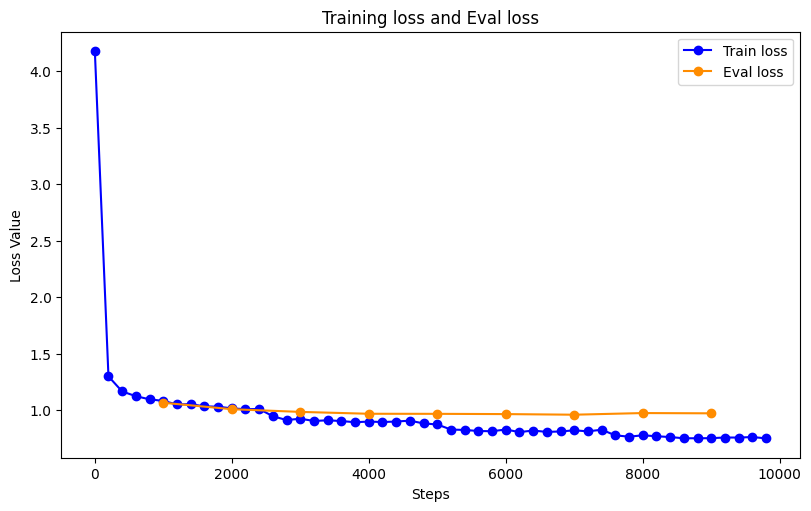

In [9]:
plt.figure(figsize=(8,5), layout="constrained")
plt.plot(train_steps, train_loss, label="Train loss", marker="o", color="b")
plt.plot(eval_steps, eval_loss, label="Eval loss", marker="o", color="#FF8C00")
plt.xlabel("Steps")
plt.ylabel("Loss Value")
plt.title("Training loss and Eval loss")
plt.legend()
plt.savefig(fname="Loss_Qwen_2-5_3B.png")
plt.show()

In [6]:
import json
from matplotlib import pyplot as plt

FINE_TUNED_ACCURACY_PATH="" # this path is used to load the accuracy score from 4 metrics in .txt file

with open(FINE_TUNED_ACCURACY_PATH, "r", encoding="utf-8") as f:
    d = json.loads(f.read())
print(d)

accuracy = [d['Coherence Accuracy'], d['Fluency Accuracy']]
mae = [d['MAE Coherence'], d['MAE Fluency']]
macro_f1_score = [d['Macro F1-score Coherence'], d['Macro F1-score Fluency']]
qwk = [d['QWK Coherence'], d['QWK Fluency']]

{'Coherence Accuracy': 0.5704, 'Fluency Accuracy': 0.5185, 'Both Accuracy': 0.3558, 'MAE Coherence': 0.4884, 'MAE Fluency': 0.5485, 'Macro F1-score Coherence': 0.5425, 'Macro F1-score Fluency': 0.5051, 'QWK Coherence': 0.8638, 'QWK Fluency': 0.848}


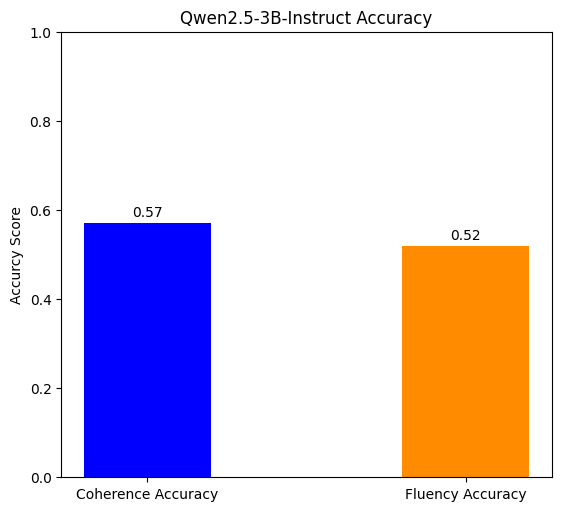

In [12]:
plt.figure(figsize=(5.5,5), layout="constrained")
bars = plt.bar(["Coherence Accuracy", "Fluency Accuracy"], height=accuracy, width=0.4, color=["#0000FF","#FF8C00"])
plt.ylim((0, 1.0))
plt.bar_label(bars, padding=3, fmt='%.2f')
plt.ylabel("Accurcy Score")
plt.title("Qwen2.5-3B-Instruct Accuracy")
plt.savefig("qwen3B_accuracy_coherence_fluency.png")
plt.show()

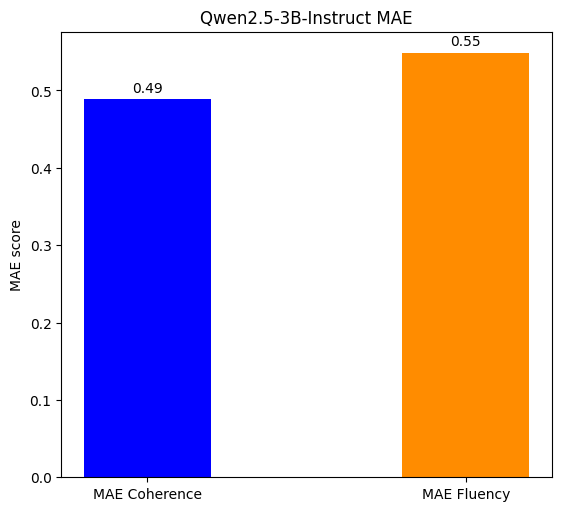

In [13]:
plt.figure(figsize=(5.5,5), layout="constrained")
bars = plt.bar(["MAE Coherence", "MAE Fluency"], height=mae, width=0.4, color=["#0000FF","#FF8C00"])
plt.ylabel("MAE score")
plt.bar_label(bars, padding=3, fmt="%.2f")
plt.title("Qwen2.5-3B-Instruct MAE")
plt.savefig("qwen3B_mae_coherence_fluency.png")
plt.show()

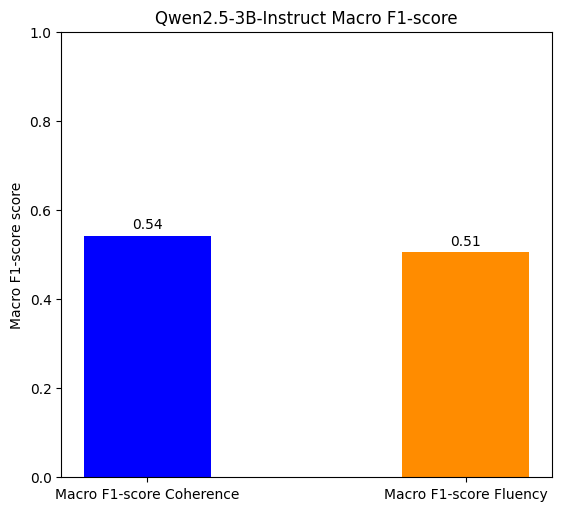

In [14]:
plt.figure(figsize=(5.5,5), layout="constrained")
bars = plt.bar(["Macro F1-score Coherence", "Macro F1-score Fluency"], height=macro_f1_score, width=0.4, color=["#0000FF","#FF8C00"])
plt.ylim(0,1.0)
plt.ylabel("Macro F1-score score")
plt.bar_label(bars, padding=3, fmt="%.2f")
plt.title("Qwen2.5-3B-Instruct Macro F1-score")
plt.savefig("qwen3B_macro_f1-score_coherence_fluency.png")
plt.show()

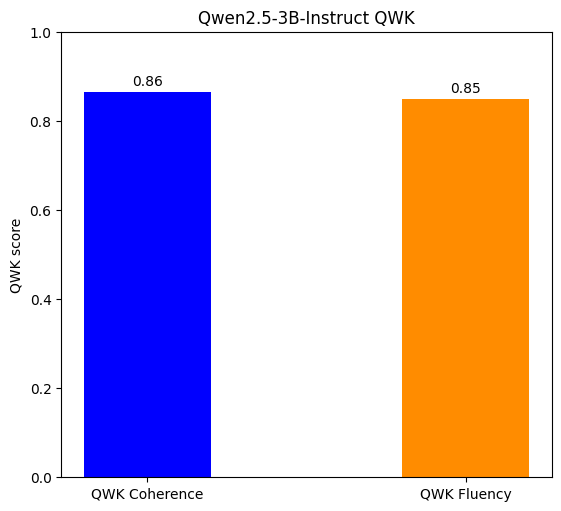

In [15]:
plt.figure(figsize=(5.5,5), layout="constrained")
bars = plt.bar(["QWK Coherence", "QWK Fluency"], height=qwk, width=0.4, color=["#0000FF","#FF8C00"])
plt.ylim(0,1.0)
plt.ylabel("QWK score")
plt.bar_label(bars, padding=3, fmt="%.2f")
plt.title("Qwen2.5-3B-Instruct QWK")
plt.savefig("qwen3B_qwk_coherence_fluency.png")
plt.show()